# Explore here

In [17]:
# Your code here
import pandas as pd 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import joblib   

url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
df = pd.read_csv(url)
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


Convertimos las columnas de fecha a datetime y se establece como indice.

In [ ]:
df["date"]= pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df=df.sort_index()

In [19]:
df = df.asfreq("D")
df["sales"] = df["sales"].ffill()

Debemos de visyualisar los datos y descomponerlos usaremos plt

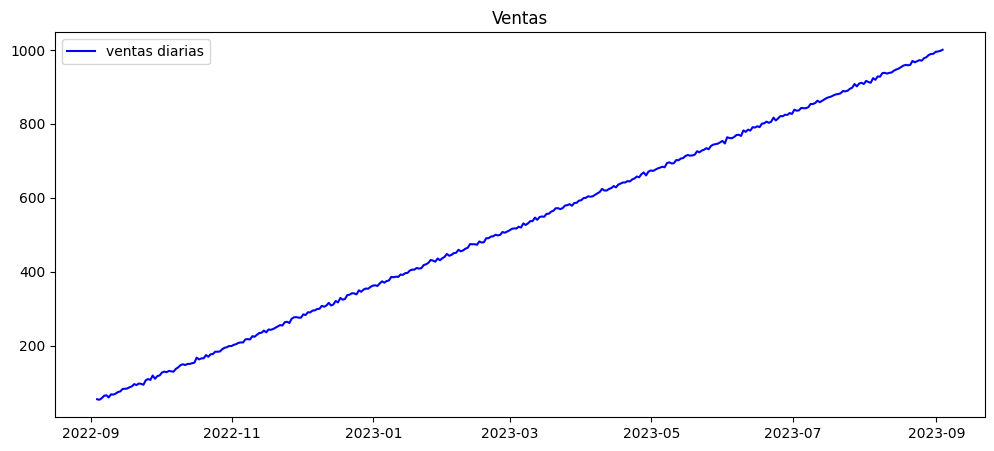

In [24]:
plt.figure(figsize=(12,5))
plt.plot(df["sales"], label="ventas diarias", color = "blue")
plt.title("Ventas")
plt.legend()
plt.show()


Como podemos ver la grafica no es la mejor lo que trataremos de reducir la informacion a la ultima semana para poder detallar un poco mejor la grafica y poder ver los datos mas exactos.

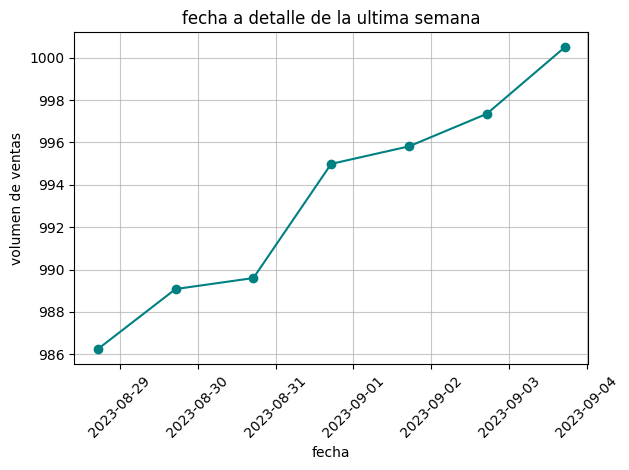

In [22]:
ult_sema = df.tail(7)

plt.Figure(figsize=(10,6))
plt.plot(
    ult_sema.index,
    ult_sema["sales"],
    marker="o",
    linestyle="-",
    color="teal"
    )

plt.title("fecha a detalle de la ultima semana")
plt.xlabel("fecha")
plt.ylabel("volumen de ventas")
plt.grid(True, linestyle ="-", alpha = 0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Aquí podemos responder a las preguntas que nos plantean en el ejercicio:
¿Cuál es el tensor de la serie temporal?
R=Al observar los registros en el indice el tensor es de unidad diaria
¿Cuál es la tendencia?
R= En las grafias se logra observar que la tendencia es alcista
¿Es estacionaria?
R= No es estacionaria ya que suale tener picos altos y picos bajos por lo que no se queda estacionaria.
¿Existe variabilidad o presencia de ruido? 
R= En este ejercicio puede haber pero eso lo confirmaremos.

Es momento de entrenar nuestro modelo arima

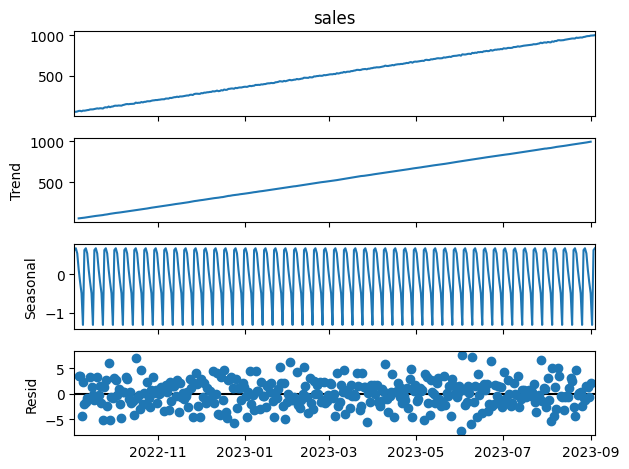

In [25]:
descompocicion= seasonal_decompose(df["sales"], model="additive")
descompocicion.plot()
plt.show()

Entrenamiento del modelo arima

In [26]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]


In [28]:
print("Buscando los mejores parámetros con auto_arima...")
stepwise_model = auto_arima(train, start_p=1, start_q=1,
                           max_p=3, max_q=3, 
                           seasonal=False, 
                           d=1, trace=True,
                           error_action='ignore',  
                           suppress_warnings=True, 
                           stepwise=True)
print(f"Mejor modelo encontrado: {stepwise_model.order}")

Buscando los mejores parámetros con auto_arima...
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1475.512, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1675.428, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1578.564, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1475.165, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1763.761, Time=0.01 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1475.495, Time=0.13 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=1479.028, Time=0.12 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1762.924, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 0.682 seconds
Mejor modelo encontrado: (0, 1, 1)


In [29]:
model = ARIMA(train, order=stepwise_model.order)
model_fit = model.fit()

In [30]:
forecast = model_fit.get_forecast(steps=len(test))
yhat = forecast.predicted_mean
conf_int = forecast.conf_int()

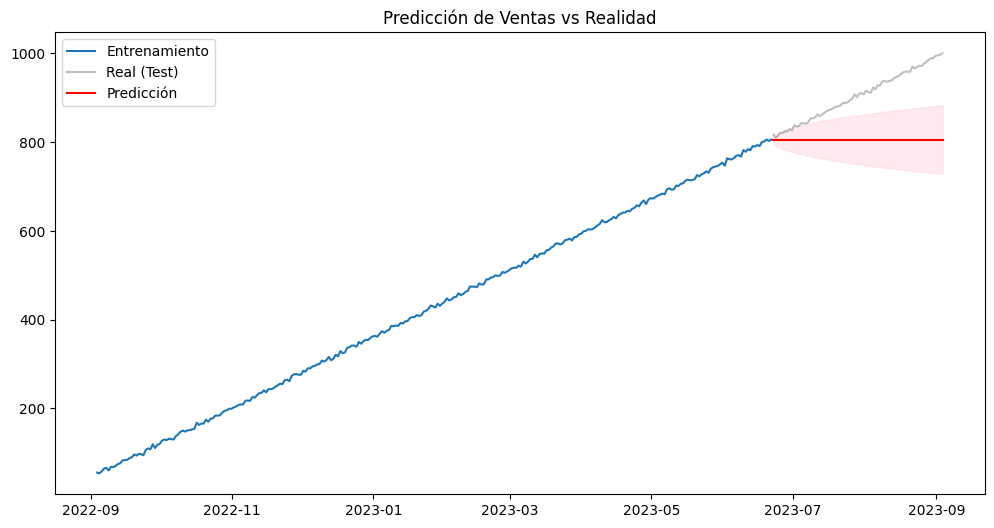

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['sales'], label='Entrenamiento')
plt.plot(test.index, test['sales'], label='Real (Test)', color='gray', alpha=0.5)
plt.plot(test.index, yhat, label='Predicción', color='red')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.title('Predicción de Ventas vs Realidad')
plt.legend()
plt.show()

In [34]:
import os
import joblib


directorio_modelos = os.path.join('..', 'models')

if not os.path.exists(directorio_modelos):
    os.makedirs(directorio_modelos)
else:
    print(f"✅ La carpeta '{directorio_modelos}' ya existe.")

ruta_final = os.path.join(directorio_modelos, 'arima_sales_model.pkl')
joblib.dump(model_fit, ruta_final)


✅ La carpeta '../models' ya existe.


['../models/arima_sales_model.pkl']